In [20]:
import os
import glob
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import cv2

In [21]:
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 16
EPOCHS      = 5
AUTOTUNE    = tf.data.AUTOTUNE

img_paths = sorted(
    glob.glob("images/*.png"),
    key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
)
mask_paths = sorted(
    glob.glob("best_masks/*.png"),
    key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
)

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    img_paths, mask_paths, test_size=0.2, random_state=42
)

def load_and_preprocess(img_path, mask_path):
    # Read image
    img  = tf.io.read_file(img_path)
    img  = tf.image.decode_png(img, channels=1)
    img  = tf.image.convert_image_dtype(img, tf.float32)
    img  = tf.image.resize(img, IMG_SIZE)

    # Read mask
    m   = tf.io.read_file(mask_path)
    m   = tf.image.decode_png(m, channels=1)
    m   = tf.image.convert_image_dtype(m, tf.float32)
    m   = tf.image.resize(m, IMG_SIZE)

    return img, m

In [22]:
train_ds = (
    tf.data.Dataset
      .from_tensor_slices((train_imgs, train_masks))
      .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
      .shuffle(buffer_size=len(train_imgs))
      .batch(BATCH_SIZE)
      .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
      .from_tensor_slices((val_imgs, val_masks))
      .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
      .batch(BATCH_SIZE)
      .prefetch(AUTOTUNE)
)


In [23]:
def build_seg_model(input_shape=(128,128,1)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D(2)(x)        
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)        
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)          

    # Decoder
    x = layers.UpSampling2D(2)(x) 
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D(2)(x)       
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D(2)(x)      

    # Output mask
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    return models.Model(inputs, outputs, name="SegNet")

In [24]:
model = build_seg_model()
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

# 7) Example: evaluate on validation set
loss, acc = model.evaluate(val_ds)
print(f"Validation loss: {loss:.4f}, accuracy: {acc:.4f}")

Epoch 1/5
539/539 [==============================] - 62s 47ms/step - loss: 0.1042 - accuracy: 0.9556 - val_loss: 0.0528 - val_accuracy: 0.9739
Epoch 2/5
539/539 [==============================] - 70s 48ms/step - loss: 0.0417 - accuracy: 0.9783 - val_loss: 0.0342 - val_accuracy: 0.9808
Epoch 3/5
539/539 [==============================] - 60s 39ms/step - loss: 0.0337 - accuracy: 0.9811 - val_loss: 0.0301 - val_accuracy: 0.9823
Epoch 4/5
539/539 [==============================] - 64s 45ms/step - loss: 0.0306 - accuracy: 0.9822 - val_loss: 0.0294 - val_accuracy: 0.9826
Epoch 5/5
135/135 [==============================] - 2s 13ms/step - loss: 0.0284 - accuracy: 0.9829
Validation loss: 0.0284, accuracy: 0.9829


1/1 [==============================] - 0s 40ms/step


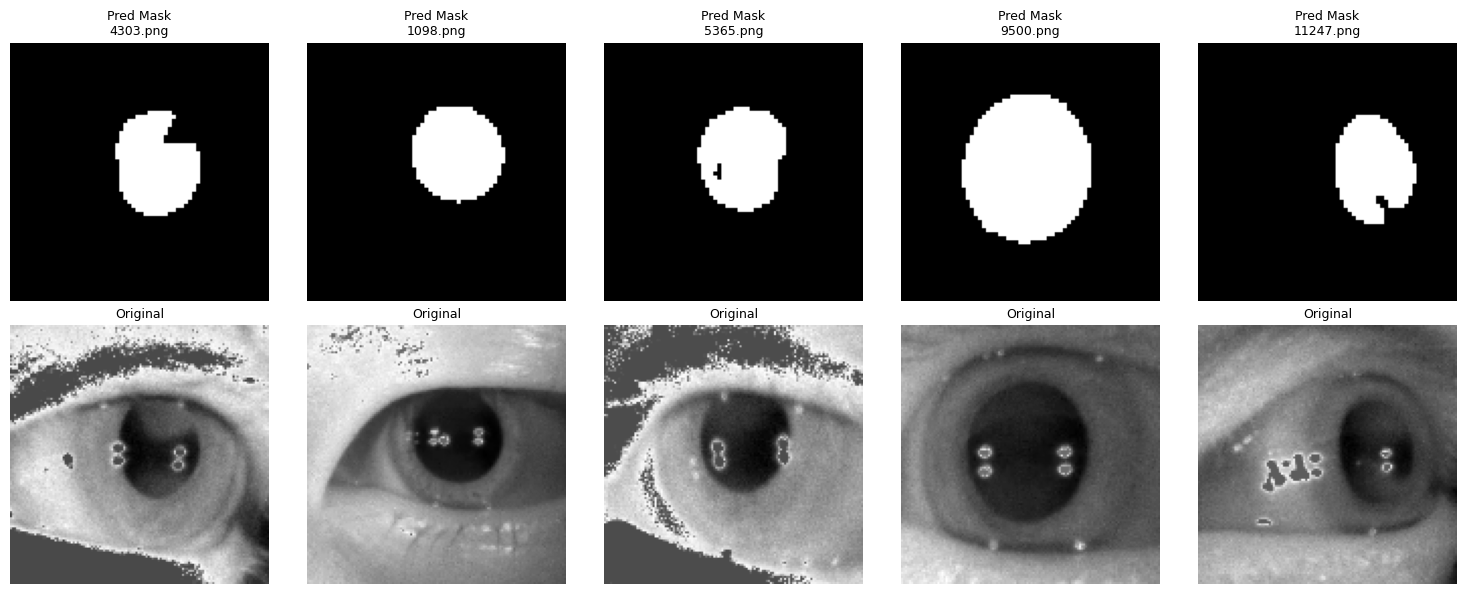

In [25]:
#inference 
import matplotlib.pyplot as plt
def predict_mask(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    img = img.reshape((1, *IMG_SIZE, 1)) 

    pred_mask = model.predict(img)
    pred_mask = (pred_mask > 0.5).astype("uint8")  
    return pred_mask[0].squeeze() 

N = 5
fig, axes = plt.subplots(2, N, figsize=(3 * N, 6))

for i in range(N):
    # Paths and data
    img_path = train_imgs[i]
    mask_pred = predict_mask(img_path)            
    img_orig = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_orig = cv2.resize(img_orig, (128, 128))   

    # Top row: predicted mask
    ax = axes[0, i]
    ax.imshow(mask_pred, cmap='gray')
    ax.set_title(f"Pred Mask\n{os.path.basename(img_path)}", fontsize=9)
    ax.axis('off')

    # Bottom row: original image
    ax = axes[1, i]
    ax.imshow(img_orig, cmap='gray')
    ax.set_title("Original", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [26]:

def overlay_mask(image_path, mask):
    # 1) load & resize gray
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)

    # 2) make it BGR
    img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # 3) boolean mask of shape (H,W)
    mask_bool = mask.astype(bool)

    # 4) overlay: copy original, then for each (i,j) where mask is True, set [B,G,R]=255
    overlay = img_bgr.copy()
    overlay[mask_bool, :] = (255, 255, 255)

    return overlay

num_pics = len(train_imgs)  
window_name = "Pupil Segmentation"
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

for img_path in train_imgs:
    # 1) predict and overlay
    mask_pred = predict_mask(img_path)         
    overlaid  = overlay_mask(img_path, mask_pred)

    # 2) display in the same window
    cv2.imshow(window_name, overlaid)

    # 3) wait ~30ms between frames; exit on 'q'
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

# clean up
cv2.destroyWindow(window_name)

1/1 [==============================] - 0s 43ms/step


In [27]:
# save the model
model.save("mask_model.keras")


In [28]:
# convert to tflite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("mask_model.tflite", "wb") as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: C:\Users\NateLy\AppData\Local\Temp\tmp0cml13ap\assets


INFO:tensorflow:Assets written to: C:\Users\NateLy\AppData\Local\Temp\tmp0cml13ap\assets
